In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')


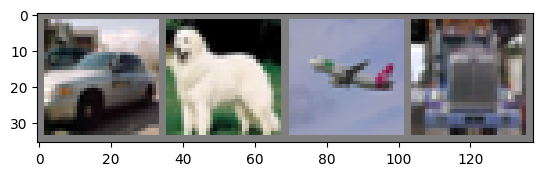

car   dog   plane truck


In [ ]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)# #the output is  (6,28,28). The data has 3 channels, 6=number of filters, 5= size of the filter
        self.pool = nn.MaxPool2d(2, 2)# output is (6,14,14)
        self.conv2 = nn.Conv2d(6, 16, 5)#output is (16,10,10)then another maxpool channel followed by a flattenning
        self.fc1 = nn.Linear(16 * 5 * 5, 120)#
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [ ]:
# Ensure We Are Running on a GPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#print("Device: ", device)
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.191
[1,  4000] loss: 1.187
[1,  6000] loss: 1.201
[1,  8000] loss: 1.140
[1, 10000] loss: 1.150
[1, 12000] loss: 1.147
[2,  2000] loss: 1.076
[2,  4000] loss: 1.074
[2,  6000] loss: 1.075
[2,  8000] loss: 1.086
[2, 10000] loss: 1.086
[2, 12000] loss: 1.060
[3,  2000] loss: 0.970
[3,  4000] loss: 1.005
[3,  6000] loss: 1.020
[3,  8000] loss: 1.023
[3, 10000] loss: 1.020
[3, 12000] loss: 1.020
[4,  2000] loss: 0.943
[4,  4000] loss: 0.964
[4,  6000] loss: 0.946
[4,  8000] loss: 0.941
[4, 10000] loss: 0.966
[4, 12000] loss: 0.964
[5,  2000] loss: 0.859
[5,  4000] loss: 0.906
[5,  6000] loss: 0.906
[5,  8000] loss: 0.919
[5, 10000] loss: 0.910
[5, 12000] loss: 0.913
[6,  2000] loss: 0.826
[6,  4000] loss: 0.834
[6,  6000] loss: 0.895
[6,  8000] loss: 0.870
[6, 10000] loss: 0.876
[6, 12000] loss: 0.878
[7,  2000] loss: 0.803
[7,  4000] loss: 0.813
[7,  6000] loss: 0.837
[7,  8000] loss: 0.841
[7, 10000] loss: 0.829
[7, 12000] loss: 0.861
[8,  2000] loss: 0.761
[8,  4000] 

In [ ]:
correct = 0
total = 0
net.eval()
test_loss = 0
correct = 0
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        test_loss += criterion(outputs, labels).item()
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

        #correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')
test_loss /= len(testloader.dataset)
print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)'.format(test_loss, correct, len(testloader.dataset),100. * correct / len(testloader.dataset)))
  # print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy of the network on the 10000 test images: 55 %
Test set: Average loss: 0.3143, Accuracy: 5519/10000 (55%)
Accuracy for class: plane is 57.8 %
Accuracy for class: car   is 74.8 %
Accuracy for class: bird  is 57.1 %
Accuracy for class: cat   is 24.7 %
Accuracy for class: deer  is 43.8 %
Accuracy for class: dog   is 43.4 %
Accuracy for class: frog  is 53.6 %
Accuracy for class: horse is 75.5 %
Accuracy for class: ship  is 71.7 %
Accuracy for class: truck is 49.5 %
